In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
! pip install dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 108.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Dagshub/Mlflow initialization

In [3]:
import dagshub
import mlflow
import mlflow.sklearn
import os

TOKEN = '773e6d0f45f4f8c8ed729b693f548555a4de31f8'

os.environ['DAGSHUB_USER_TOKEN'] = TOKEN
dagshub.auth.add_app_token(TOKEN)

dagshub.init(repo_owner='sbolk23', repo_name='IEEE-CIS-Fraud-Detection-Kaggle-Competition', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c6375154-1a4e-4303-b43a-70caf8dd5dc4&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=15d64ee9d344f81da375d680619b79f8ba519925e42f43abadf3a3859f13796f




Accessing as sbolk23

Initialized MLflow to track repo "sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition"

Repository sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition initialized!

In [4]:
TARGET = 'isFraud'

In [5]:
df_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [6]:
print('train_trancation shape:', df_transaction.shape)
print('train_identity shape:',   df_identity.shape)

train_trancation shape: (590540, 394)
train_identity shape: (144233, 41)


In [7]:
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')

In [8]:
print('Data count:',  df[TARGET].shape[0])
print('Event count:', df[TARGET].sum())

Data count: 590540
Event count: 20663


In [9]:
sorted_df = df.sort_values(by='TransactionDT')

train_size = int(sorted_df.shape[0] * .7)
val_size   = int(sorted_df.shape[0] * .15)

train_df = sorted_df.iloc[:train_size]
val_df   = sorted_df.iloc[train_size: train_size + val_size]
test_df  = sorted_df.iloc[train_size + val_size:]

print('Train shape:',      train_df.shape, '\nTrain prevalence:',      train_df[TARGET].sum() / train_df.shape[0], '\n')
print('Validation shape:', val_df.shape,   '\nValidation prevalence:', val_df[TARGET].sum()   / val_df.shape[0],   '\n')
print('Test shape:',       test_df.shape,  '\nTrain prevalence:',      test_df[TARGET].sum()  / test_df.shape[0],  '\n')

Train shape: (413378, 434) 
Train prevalence: 0.03516878014795175 

Validation shape: (88581, 434) 
Validation prevalence: 0.03434145019812375 

Test shape: (88581, 434) 
Train prevalence: 0.03480430340592226 



In [10]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val   = val_df.drop(columns=[TARGET])
y_val   = val_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

# Data Cleaning

# Uninformative Columns

In [11]:
# TransactionID and TransactionDT are not informative feature so we remove it

irrelevant_cols = [
    'TransactionID',
    'TransactionDT',
]

# Preprocessing Pipeline

In [12]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Drop irrelevant columns
irrelevant_col_dropper = ColumnTransformer(
    transformers=[
        ('drop', 'drop', irrelevant_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
).set_output(transform='pandas')



# No imputation needed for numeric features, just using xgboost NA support 


# No encoding needed for categorical features, just using xgboost categorical native support
def to_categorical(X):
    return X.astype('category')
    
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('cast',    FunctionTransformer(to_categorical, feature_names_out='one-to-one'))
])

prep = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', make_column_selector(dtype_include='number')),
        ('cat', cat_pipeline,  make_column_selector(dtype_exclude='number')),
    ],
    verbose_feature_names_out=False,
).set_output(transform='pandas')



# Full preprocessor pipeline
preprocessor = Pipeline([
    ('dropper',         irrelevant_col_dropper),
    ('prep',            prep),
])

# Full Pipeline

In [28]:
from xgboost import XGBClassifier

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        XGBClassifier()),
])

preprocessor_configs = {
    'prep__cat__imputer__strategy':   ['constant'],
    'prep__cat__imputer__fill_value': ['missing'],
}

# model_configs = {
#     # --- Structural Parameters ---
#     'n_estimators':         [1000,], # Number of trees
#     'max_depth':            [4, 5, 6,],     # Tree depth; IEEE sweet spot is usually 6-12
#     'min_child_weight':     [10, 50, 100],    # Higher values prevent overfitting on tiny noise clusters
    
#     # --- Inner Regularization (The "Loss Modifiers") ---
#     'reg_lambda':           [1, 5, 10],      # L2 regularization (Smooths leaf weights)
#     'reg_alpha':            [0, .1, 1],      # L1 regularization (Encourages feature sparsity)
#     'gamma':                [1, 5],      # Minimum loss reduction to split (Pruning)
    
#     # --- Learning & Sampling ---
#     'learning_rate':        [.01, .05,], # Shrinkage; lower requires more n_estimators
#     'subsample':            [.6, .7],             # Row sampling (prevent overfitting)
#     'colsample_bytree':     [.5, .6],             # Feature sampling per tree
#     'colsample_bylevel':    [1],             # Feature sampling per level
    
#     # --- Imbalance & Specialized ---
#     'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
#     'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
#     # --- Technical Constants ---
#     'tree_method':          ['hist'],          # Required for large datasets + categorical support
#     'enable_categorical':   [True],            # Must be True for your cat_pipeline
#     'random_state':         [1337],
#     'n_jobs':               [-1],
#     'eval_metric':          ['auc'],
#     'device':               ['cuda']
# }

model_configs = {
    # --- Structural Parameters ---
    'n_estimators':         [225,], # Number of trees
    'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
    'min_child_weight':     [50,],    # Higher values prevent overfitting on tiny noise clusters
    
    # --- Inner Regularization (The "Loss Modifiers") ---
    'reg_lambda':           [2,],      # L2 regularization (Smooths leaf weights)
    'reg_alpha':            [.5],      # L1 regularization (Encourages feature sparsity)
    'gamma':                [3,],      # Minimum loss reduction to split (Pruning)
    
    # --- Learning & Sampling ---
    'learning_rate':        [.05,], # Shrinkage; lower requires more n_estimators
    'subsample':            [.8],             # Row sampling (prevent overfitting)
    'colsample_bytree':     [.8],             # Feature sampling per tree
    'colsample_bylevel':    [1],             # Feature sampling per level
    
    # --- Imbalance & Specialized ---
    'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
    'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
    # --- Technical Constants ---
    'tree_method':          ['hist'],          # Required for large datasets + categorical support
    'enable_categorical':   [True],            # Must be True for your cat_pipeline
    'random_state':         [1337],
    'n_jobs':               [-1],
    'eval_metric':          ['auc'],
    'device':               ['cuda']
}

# MLflow Logging 

# Model Parameters & Metrics Logging Helper function

In [14]:
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    log_loss, 
    brier_score_loss, 
    f1_score, 
    precision_score, 
    recall_score, 
    balanced_accuracy_score, 
    matthews_corrcoef,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    roc_curve
)

def log_model_parameters_metrics(y_true, y_prob, prefix):
    
    # Best threshold for current predicition probabilities
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[min(np.argmax(f1_scores), len(thresholds) - 1)]

    y_pred = (y_prob >= best_threshold).astype(int)

    
    print(f'Logging model metrics on {prefix} set...')
    
    # Metrics independent from threshold
    auc_roc         = roc_auc_score(y_true, y_prob)
    auc_pr          = average_precision_score(y_true, y_prob)
    model_log_loss  = log_loss(y_true, y_prob)
    model_brier     = brier_score_loss(y_true, y_prob)

    mlflow.log_metric(f'{prefix}_auc_roc',  auc_roc)
    mlflow.log_metric(f'{prefix}_auc_pr',   auc_pr)
    mlflow.log_metric(f'{prefix}_log_loss', model_log_loss)
    mlflow.log_metric(f'{prefix}_brier',    model_brier)

    
    # Metrics dependent on best threshold
    model_f1        = f1_score(y_true, y_pred)
    model_precision = precision_score(y_true, y_pred)
    model_recall    = recall_score(y_true, y_pred)
    
    mlflow.log_metric(f'{prefix}_f1',        model_f1)
    mlflow.log_metric(f'{prefix}_precision', model_precision)
    mlflow.log_metric(f'{prefix}_recall',    model_recall)

    # Best threshold
    mlflow.log_metric(f'{prefix}_best_threshold', best_threshold)

    
    # Log confusion matrix and classification report
    cm     = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    
    mlflow.log_text(f'Confusion Matrix:\n{cm}',          f'{prefix}_confusion_matrix.txt')
    mlflow.log_text(f'Classification Report:\n{report}', f'{prefix}_classification_report.txt')


# Model Metrics Curves Logging Helper Function

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def log_model_metrics_curves(y_true, y_prob, prefix):
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Log ROC curve
    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    ax_roc.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
    ax_roc.plot([0, 1], [0, 1], linestyle='--')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'ROC Curve - {prefix}')
    ax_roc.legend(loc='lower right')
    mlflow.log_figure(fig_roc, f'{prefix}_roc_curve.png')
    plt.close(fig_roc)

    # Log Precision-Recall curve
    precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recalls, precisions)

    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
    ax_pr.plot(recalls, precisions, label=f'PR AUC = {pr_auc:.4f}')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'Precision-Recall Curve - {prefix}')
    ax_pr.legend(loc='lower left')
    mlflow.log_figure(fig_pr, f'{prefix}_pr_curve.png')
    plt.close(fig_pr)


    # Best threshold for current predicition probabilities
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[min(np.argmax(f1_scores), len(thresholds) - 1)]

    y_pred = (y_prob >= best_threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    
    # Log Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {prefix}")
    mlflow.log_figure(fig, f"{prefix}_confusion_matrix.png")

In [77]:
from sklearn.model_selection import ParameterGrid, GridSearchCV
from sklearn.base import clone

model_configs = {
    # --- Structural Parameters ---
    'n_estimators':         [2000], # Number of trees
    'early_stopping_rounds': [50],
    'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
    'min_child_weight':     [200],    # Higher values prevent overfitting on tiny noise clusters
    
    # --- Inner Regularization (The "Loss Modifiers") ---
    'reg_lambda':           [600,],      # L2 regularization (Smooths leaf weights)
    'reg_alpha':            [600,],      # L1 regularization (Encourages feature sparsity)
    'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
    # --- Learning & Sampling ---
    'learning_rate':        [.05], # Shrinkage; lower requires more n_estimators
    'subsample':            [.8,],             # Row sampling (prevent overfitting)
    'colsample_bytree':     [.85,],             # Feature sampling per tree
    'colsample_bylevel':    [1],             # Feature sampling per level
    
    # --- Imbalance & Specialized ---
    'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
    # 'scale_pos_weight':     [30.0],  # Handle imbalance (Ratio of negative/positive)
    'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
    # --- Technical Constants ---
    'tree_method':          ['hist'],          # Required for large datasets + categorical support
    'enable_categorical':   [True],            # Must be True for your cat_pipeline
    'random_state':         [1337],
    'n_jobs':               [-1],
    'eval_metric':          ['auc'],
    'device':               ['cuda']
}


for prep_param in ParameterGrid(preprocessor_configs):
    preprocessor = clone(full_pipeline.named_steps['preprocessor'])
    preprocessor.set_params(**prep_param)

    print('Starting fitting & transforming X_train, X_val...')

    X_train_t = preprocessor.fit_transform(X_train, y_train)
    print('fit_transform X_train finished...')

    X_val_t   = preprocessor.transform(X_val)
    print('transform X_val finished...')

    print(prep_param)

    for model_param in ParameterGrid(model_configs):    
        model = clone(full_pipeline.named_steps['model'])
        model.set_params(**model_param)

        print('Currently running model with params:', model_param)
        
        print('Starting training model on X_train_t...')
        model.fit(
            X_train_t, y_train
            eval_set=[(X_val_t, y_val)],
            verbose=100
        )
        print('Finished training model on X_train_t...')

        print('Starting predicting on X_train_t...')
        y_train_prob = model.predict_proba(X_train_t)[:, 1]
        print('Finished predicting on X_train_t...')
        
        print('Starting predicting on X_val_t...')
        y_val_prob   = model.predict_proba(X_val_t)[:, 1]
        print('Finished predicting on X_val_t...')

        print('train_roc_score:', roc_auc_score(y_train, y_train_prob))
        print('test_roc_score:',  roc_auc_score(y_val, y_val_prob))


Starting fitting & transforming X_train, X_val...
fit_transform X_train finished...
transform X_val finished...
{'prep__cat__imputer__fill_value': 'missing', 'prep__cat__imputer__strategy': 'constant'}
Currently running model with params: {'colsample_bylevel': 1, 'colsample_bytree': 0.85, 'device': 'cuda', 'early_stopping_rounds': 50, 'enable_categorical': True, 'eval_metric': 'auc', 'gamma': 0, 'learning_rate': 0.05, 'max_delta_step': 0, 'max_depth': 10, 'min_child_weight': 200, 'n_estimators': 2000, 'n_jobs': -1, 'random_state': 1337, 'reg_alpha': 600, 'reg_lambda': 600, 'scale_pos_weight': 27.434310083918007, 'subsample': 0.8, 'tree_method': 'hist'}
Starting training model on X_train_t...
[0]	validation_0-auc:0.83996
[100]	validation_0-auc:0.89322
[200]	validation_0-auc:0.90495
[300]	validation_0-auc:0.90896
[400]	validation_0-auc:0.91172
[500]	validation_0-auc:0.91362
[600]	validation_0-auc:0.91495
[700]	validation_0-auc:0.91558
[800]	validation_0-auc:0.91622
[900]	validation_0-auc

Start MLflow logging
Starting fitting & transforming X_train, X_val...
fit_transform X_train finished...
transform X_val finished...
{'prep__cat__imputer__fill_value': 'missing', 'prep__cat__imputer__strategy': 'constant'}
Currently running model with params: {'colsample_bylevel': 1, 'colsample_bytree': 0.6, 'device': 'cuda', 'early_stopping_rounds': 50, 'enable_categorical': True, 'eval_metric': 'auc', 'gamma': 1, 'learning_rate': 0.05, 'max_delta_step': 0, 'max_depth': 6, 'min_child_weight': 200, 'n_estimators': 2000, 'n_jobs': -1, 'random_state': 1337, 'reg_alpha': 0.5, 'reg_lambda': 2, 'scale_pos_weight': 27.434310083918007, 'subsample': 0.6, 'tree_method': 'hist'}
Starting training model on X_train_t...
[0]	validation_0-auc:0.82037
[100]	validation_0-auc:0.89275
[200]	validation_0-auc:0.90383
[300]	validation_0-auc:0.90887
[400]	validation_0-auc:0.91138
[500]	validation_0-auc:0.91344
[600]	validation_0-auc:0.91544
[700]	validation_0-auc:0.91689
[800]	validation_0-auc:0.91747
[803]

2026/05/05 10:51:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 10:52:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_Training__n_estimators_2000__early_stop_50__max_depth_6__min_child_weight_200__reg_lambda_2__reg_alpha_0.5__gamma_1__lr_0.05__subsample_0.6__colsample_bytree_0.6__colsample_bylevel_1__scale_pos_weight_27.434310083918007__max_delta_step_0 at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/9/runs/7adf847984ef4965921fc6bce5fa9ca0
🧪 View experiment at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/9


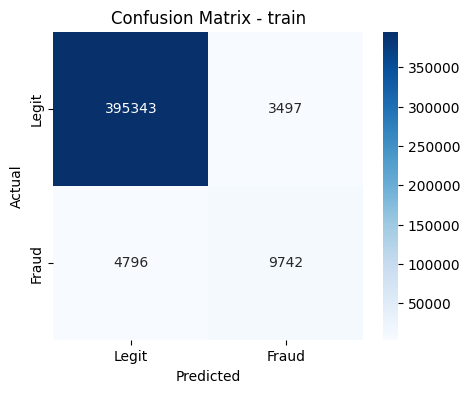

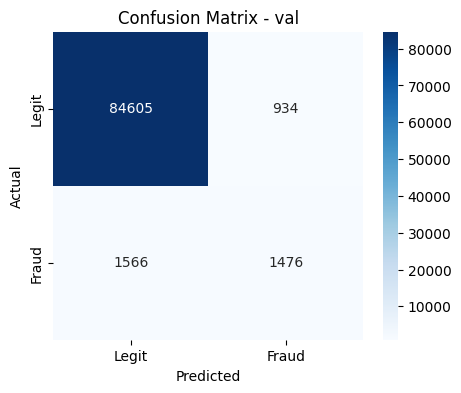

In [80]:
from sklearn.model_selection import ParameterGrid, GridSearchCV
from sklearn.base import clone

model_configs = {
    # --- Structural Parameters ---
    'n_estimators':         [2000], # Number of trees
    'max_depth':            [10,],     # Tree depth; IEEE sweet spot is usually 6-12
    'min_child_weight':     [200],    # Higher values prevent overfitting on tiny noise clusters
    
    # --- Inner Regularization (The "Loss Modifiers") ---
    'reg_lambda':           [600,],      # L2 regularization (Smooths leaf weights)
    'reg_alpha':            [600,],      # L1 regularization (Encourages feature sparsity)
    'gamma':                [0],      # Minimum loss reduction to split (Pruning)
    
    # --- Learning & Sampling ---
    'learning_rate':        [.05], # Shrinkage; lower requires more n_estimators
    'subsample':            [.8,],             # Row sampling (prevent overfitting)
    'colsample_bytree':     [.85,],             # Feature sampling per tree
    'colsample_bylevel':    [1],             # Feature sampling per level
    
    # --- Imbalance & Specialized ---
    'scale_pos_weight':     [len(y_train[y_train==0]) / len(y_train[y_train==1])],  # Handle imbalance (Ratio of negative/positive)
    # 'scale_pos_weight':     [30.0],  # Handle imbalance (Ratio of negative/positive)
    'max_delta_step':       [0,],         # Helps stabilize updates in imbalanced classes
    
    # --- Technical Constants ---
    'tree_method':          ['hist'],          # Required for large datasets + categorical support
    'enable_categorical':   [True],            # Must be True for your cat_pipeline
    'random_state':         [1337],
    'n_jobs':               [-1],
    'eval_metric':          ['auc'],
    'device':               ['cuda']
}



print('Start MLflow logging')

for prep_param in ParameterGrid(preprocessor_configs):
    experiment_name = (
        f'IEEE-CIS_Fraud_Detection_XGBoost_Training'
        f'__prep_v0'
    )
    
    mlflow.set_experiment(experiment_name)
    
    preprocessor = clone(full_pipeline.named_steps['preprocessor'])
    preprocessor.set_params(**prep_param)

    print('Starting fitting & transforming X_train, X_val...')

    X_train_t = preprocessor.fit_transform(X_train, y_train)
    print('fit_transform X_train finished...')

    X_val_t   = preprocessor.transform(X_val)
    print('transform X_val finished...')

    print(prep_param)
    with mlflow.start_run(run_name='XGBoost_Cleaning'):
        # Logging Data Split 
        mlflow.log_param('split_method',                'Chronological')
        
        mlflow.log_param('train_df_ratio',              len(train_df) / len(df))
        mlflow.log_param('val_df_ratio',                len(val_df)   / len(df))
        mlflow.log_param('test_df_ratio',               len(test_df)  / len(df))

        mlflow.log_metric('train_df_prevalence',        train_df[TARGET].sum() / train_df.shape[0])
        mlflow.log_metric('val_df_prevalence',          val_df[TARGET].sum()   / val_df.shape[0])
        mlflow.log_metric('test_df_prevalence',         test_df[TARGET].sum()  / test_df.shape[0])
        
        
        # Logging cleaning parameters
        mlflow.log_param('irrelevant_cols',             str(irrelevant_cols))
        mlflow.log_param('n_irrelevant_cols_dropped',   len(irrelevant_cols))
        
        mlflow.log_param('cat_imputer_strategy',        prep_param['prep__cat__imputer__strategy'])
        mlflow.log_param('cat_imputer_fill_value',      prep_param['prep__cat__imputer__fill_value'])
        
        mlflow.log_param('num_imputer_strategy',        'native')
        

        # Logging cleaning metrics
        mlflow.log_metric('X_train_rows_before', X_train.shape[0])
        mlflow.log_metric('X_train_cols_before', X_train.shape[1])
        mlflow.log_metric('X_train_cols_after',  X_train_t.shape[1])
        mlflow.log_metric('X_val_rows_before',   X_val.shape[0])
        mlflow.log_metric('X_val_cols_before',   X_val.shape[1])
        mlflow.log_metric('X_val_cols_after',    X_val_t.shape[1])
        mlflow.log_metric('fraud_rate_train',    y_train.mean())
        mlflow.log_metric('fraud_rate_val',      y_val.mean())


    for model_param in ParameterGrid(model_configs):    
        model = clone(full_pipeline.named_steps['model'])
        model.set_params(**model_param)

        print('Currently running model with params:', model_param)
        
        print('Starting training model on X_train_t...')
        model.fit(X_train_t, y_train)
        print('Finished training model on X_train_t...')

        print('Starting predicting on X_train_t...')
        y_train_prob = model.predict_proba(X_train_t)[:, 1]
        print('Finished predicting on X_train_t...')
        
        print('Starting predicting on X_val_t...')
        y_val_prob   = model.predict_proba(X_val_t)[:, 1]
        print('Finished predicting on X_val_t...')

        print('train_auc_roc_score:', roc_auc_score(y_train, y_train_prob))
        print('test_auc_roc_score:',  roc_auc_score(y_val, y_val_prob))

        n_estimators      = model_param['n_estimators']
        max_depth         = model_param['max_depth']
        min_child_weight  = model_param['min_child_weight']
        learning_rate     = model_param['learning_rate']
        reg_lambda        = model_param['reg_lambda']
        reg_alpha         = model_param['reg_alpha']
        gamma             = model_param['gamma']
        subsample         = model_param['subsample']
        colsample_bytree  = model_param['colsample_bytree']
        colsample_bylevel = model_param['colsample_bylevel']
        scale_pos_weight  = model_param['scale_pos_weight']
        max_delta_step    = model_param['max_delta_step']
        
        run_name = (
            f'XGBoost_Training'
            f'__n_estimators_{n_estimators}'
            f'__max_depth_{max_depth}'
            f'__min_child_weight_{min_child_weight}'
            f'__reg_lambda_{reg_lambda}'
            f'__reg_alpha_{reg_alpha}'
            f'__gamma_{gamma}'
            f'__lr_{learning_rate}'
            f'__subsample_{subsample}'
            f'__colsample_bytree_{colsample_bytree}'
            f'__colsample_bylevel_{colsample_bylevel}'
            f'__scale_pos_weight_{scale_pos_weight}'
            f'__max_delta_step_{max_delta_step}'
        )

        # Start logging
        with mlflow.start_run(run_name=run_name):
            print('Logging model training results on mlflow...')

            print('Loggin model parameters...')
            for key, val in model_param.items():
                mlflow.log_param(key, val)
            
            log_model_parameters_metrics(y_train, y_train_prob, 'train')
            log_model_parameters_metrics(y_val,   y_val_prob,   'val')
            
            log_model_metrics_curves(y_train, y_train_prob, 'train')
            log_model_metrics_curves(y_val,   y_val_prob,   'val')

            # Log full pipeline
            full_pipe = Pipeline([
                ('preprocessor', preprocessor),
                ('model',        model)
            ])
            
            model_info = mlflow.sklearn.log_model(
                sk_model=full_pipe,
                artifact_path='pipeline'
            )
            
            mlflow.set_tag('model_id', model_info.model_id)
            mlflow.set_tag('model_type', 'XGBClassifier')

            
            # Log feature importance
            importance_df = pd.DataFrame({
                'feature':    preprocessor.get_feature_names_out(),
                'importance': model.feature_importances_,
            }).sort_values('importance', ascending=False)
            
            importance_df.to_csv('feature_importances.csv', index=False)
            mlflow.log_artifact('feature_importances.csv')
            
            fig, ax = plt.subplots(figsize=(10, 8))
            top20 = importance_df.head(20)
            ax.barh(top20['feature'], top20['importance'])
            ax.set_title('Top 20 Feature Importances')
            ax.set_xlabel('Importance')
            plt.tight_layout()
            mlflow.log_figure(fig, 'top20_feature_importances.png')
            plt.close()

In [26]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_pred = final_model.predict(X_val)

# cm = confusion_matrix(y_val, y_pred)

# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])

# disp.plot(cmap=plt.cm.Blues, values_format='d')
# plt.title('Confusion Matrix: Fraud Detection')
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_auc_score, RocCurveDisplay

# y_prob = final_model.predict_proba(X_val)[:, 1]

# auc_score = roc_auc_score(y_val, y_prob)
# print(f"Your ROC AUC Score: {auc_score:.4f}")

# fig, ax = plt.subplots(figsize=(8, 6))
# RocCurveDisplay.from_predictions(y_val, y_prob, ax=ax, name=f"Logistic Regression")

# ax.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random (0.5)')

# ax.set_title(f'ROC Curve (AUC = {auc_score:.4f})')
# ax.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# y_pred = final_model.predict_proba(X_val)[:, 1]

# precision, recall, _ = precision_recall_curve(y_val, y_pred)
# average_precision = average_precision_score(y_val, y_pred)

# fig, ax = plt.subplots(figsize=(8, 6))

# ax.plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {average_precision:.2f}')
# baseline = sum(y_val) / len(y_val)
# ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.3f})')
# ax.set_xlabel('Recall (Catching Fraud)')
# ax.set_ylabel('Precision (Accuracy of Flags)')
# ax.set_title('Precision-Recall Curve')
# ax.legend(loc="upper right")
# ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
# from sklearn.metrics import classification_report, roc_auc_score, balanced_accuracy_score

# y_pred = final_model.predict(X_val)

# print("--- CLASSIFICATION REPORT ---")
# print(classification_report(y_val, y_pred, target_names=['Legit', 'Fraud']))

# print("--- SUMMARY METRICS ---")
# print(f"ROC AUC Score:       {roc_auc_score(y_val, y_prob):.4f}")
# print(f"Balanced Accuracy:   {balanced_accuracy_score(y_val, y_pred):.4f}")